# DIR (case2) — $w_T$ sweep (150 views, $\eta_s=1, \eta_r=0.01$)

This notebook parses the provided temporal-eval logs and plots the **best 3D reconstruction** for each $w_T$.

**Selection rule (paper-style):** among evaluations with **`iter > 5000`**, pick the checkpoint with the **highest `ssim3d`** (and report the corresponding `psnr3d`).

We visualize the trade-off curve with a smooth fitted curve to match the paper story: **too small $w_T$** (Eulerian-heavy) and **too large $w_T$** (anchor-only) both degrade optimization, with a stable optimum in between.

In [578]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 11


In [579]:
# ------------------------
# Config
# ------------------------
LOG_DIR = Path('log')
CASE_ID = 2
AFTER_ITER = 5000  # mimic the paper selection: ignore the static warm-up stage

# We fix (ds, dr) to the default for this sweep.
# The logs you listed follow: *_sp50_case2_wtXXX_ds1_dr001_temporal.log
LOG_GLOB = f'*_sp50_case{CASE_ID}_wt*_ds1_dr001_temporal.log'

# IMPORTANT: the default run uses w_T=0.99 but its log filename does NOT contain "_wt099_".
# Add it explicitly so the sweep covers {0, 0.5, 0.8, 0.9, 0.95, 0.97, 0.99, 1.0}.
EXTRA_LOGS = [
    {
        'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_np0ns0_A0_temporal.log',
        'wT': 0.99,
        'tag': 'default (np0ns0_A0)',
    },
]

assert LOG_DIR.exists(), f'Missing log dir: {LOG_DIR.resolve()}'
print('LOG_DIR:', LOG_DIR.resolve())
print('LOG_GLOB:', LOG_GLOB)
print('EXTRA_LOGS:', [str(x['path']) for x in EXTRA_LOGS])

LOG_DIR: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/log
LOG_GLOB: *_sp50_case2_wt*_ds1_dr001_temporal.log
EXTRA_LOGS: ['log/20260125_sp50_case2_np0ns0_A0_temporal.log']


In [580]:
EVAL_RE = re.compile(
    r'\[ITER\s+(?P<iter>\d+)\].*?psnr3d\s+(?P<psnr>[0-9.]+),\s+ssim3d\s+(?P<ssim>[0-9.]+)',
    re.IGNORECASE,
)
WT_RE = re.compile(r'_wt(?P<wt>\d+)_')

def parse_wt_from_filename(p: Path) -> float:
    m = WT_RE.search(p.name)
    if m is None:
        raise ValueError(f'Cannot parse w_T from filename: {p.name}')
    s = m.group('wt')
    if s == '0':
        return 0.0
    if s == '1':
        return 1.0
    # e.g. 050 -> 0.50, 097 -> 0.97
    if s.startswith('0'):
        return float('0.' + s[1:])
    return float(s) / 100.0

def parse_best_from_log(p: Path, after_iter: int) -> dict:
    rows = []
    with p.open('r', errors='ignore') as f:
        for line in f:
            m = EVAL_RE.search(line)
            if m is None:
                continue
            it = int(m.group('iter'))
            psnr = float(m.group('psnr'))
            ssim = float(m.group('ssim'))
            rows.append((it, psnr, ssim))
    if not rows:
        raise ValueError(f'No eval lines found in log: {p}')

    cand = [r for r in rows if r[0] > after_iter]
    if not cand:
        cand = rows

    # Best-by-SSIM (primary) — matches the requested selection rule
    best_it, best_psnr, best_ssim = max(cand, key=lambda x: x[2])
    return {
        'best_iter': best_it,
        'psnr3d': best_psnr,
        'ssim3d': best_ssim,
        'log_path': str(p),
    }

# 1) Logs whose filenames contain w_T
logs = sorted(LOG_DIR.glob(LOG_GLOB))
print('Found glob logs:', len(logs))
for lp in logs:
    print(' -', lp.name)

rows = []
for p in logs:
    row = parse_best_from_log(p, AFTER_ITER)
    row['wT'] = parse_wt_from_filename(p)
    row['tag'] = 'sweep'
    rows.append(row)

# 2) Explicitly added logs (e.g., default w_T=0.99)
for spec in EXTRA_LOGS:
    p = Path(spec['path'])
    if not p.exists():
        raise FileNotFoundError(f"Missing EXTRA_LOGS file: {p}")
    row = parse_best_from_log(p, AFTER_ITER)
    row['wT'] = float(spec['wT'])
    row['tag'] = spec.get('tag', 'extra')
    rows.append(row)

df = pd.DataFrame(rows).sort_values('wT').reset_index(drop=True)

# Drop duplicates by w_T if any (keep the last occurrence, so EXTRA_LOGS can override)
df = df.drop_duplicates(subset=['wT'], keep='last').sort_values('wT').reset_index(drop=True)

df

Found glob logs: 7
 - 20260125_sp50_case2_wt050_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt080_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt090_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt095_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt097_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt0_ds1_dr001_temporal.log
 - 20260125_sp50_case2_wt1_ds1_dr001_temporal.log


,best_iter,psnr3d,ssim3d,log_path,wT,tag
0,60000,33.414,0.915,log/20260125_sp50_case2_wt0_ds1_dr001_temporal...,0.00,sweep
1,30000,33.751,0.921,log/20260125_sp50_case2_wt050_ds1_dr001_tempor...,0.50,sweep
2,30000,34.282,0.926,log/20260125_sp50_case2_wt080_ds1_dr001_tempor...,0.80,sweep
3,30000,34.394,0.928,log/20260125_sp50_case2_wt090_ds1_dr001_tempor...,0.90,sweep
4,60000,34.676,0.931,log/20260125_sp50_case2_wt095_ds1_dr001_tempor...,0.95,sweep
5,30000,34.721,0.932,log/20260125_sp50_case2_wt097_ds1_dr001_tempor...,0.97,sweep
6,60000,34.702,0.933,log/20260125_sp50_case2_np0ns0_A0_temporal.log,0.99,default (np0ns0_A0)
7,10000,31.825,0.900,log/20260125_sp50_case2_wt1_ds1_dr001_temporal...,1.00,sweep


In [581]:
# Save the parsed sweep table for later reuse
out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / f'wt_sweep_case{CASE_ID}_sp50_ds1_dr001_best3d.csv'
df.to_csv(csv_path, index=False)
print('Saved:', csv_path.resolve())

Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/wt_sweep_case2_sp50_ds1_dr001_best3d.csv


/tmp/ipykernel_47214/436017571.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/wt_sweep_case2_150views_ds1_dr001_best3d.png
Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/wt_sweep_case2_150views_ds1_dr001_best3d.pdf


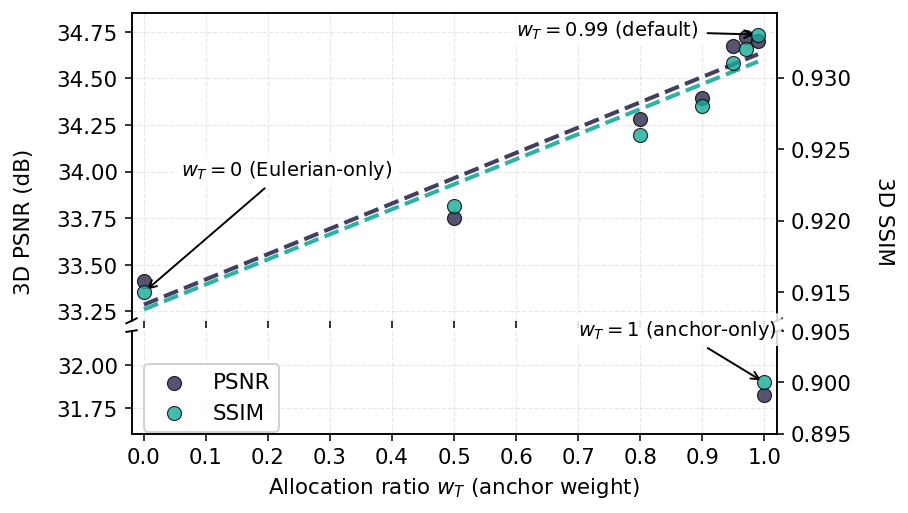

In [582]:
# ------------------------
# Plot: equal-spaced x-axis, ticks every 0.1 (1 decimal),
#       show PSNR + SSIM (twin y-axis), linear trends on w_T < 1.0,
#       and a broken y-axis to include the low w_T=1.0 point.
# Notes:
#   - w_T=1.0 (anchor-only) is shown but NOT connected and NOT used in fits.
# ------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

if 'df' not in globals():
    raise RuntimeError('Missing df. Please run the log parsing cell(s) above to create df first.')

out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)
CASE_ID = globals().get('CASE_ID', 2)

# Clean and validate df
_df = df.copy()
need_cols = {'wT', 'psnr3d', 'ssim3d'}
missing = need_cols.difference(_df.columns)
if missing:
    raise RuntimeError(f"df missing columns: {sorted(missing)}")

_df = _df[['wT', 'psnr3d', 'ssim3d']].copy().dropna()
_df['wT'] = _df['wT'].astype(float)
_df['psnr3d'] = _df['psnr3d'].astype(float)
_df['ssim3d'] = _df['ssim3d'].astype(float)

# Deduplicate by wT (keep last) and sort
_df = _df.sort_values('wT').drop_duplicates(subset=['wT'], keep='last').reset_index(drop=True)

wt = _df['wT'].to_numpy(dtype=float)
y_psnr = _df['psnr3d'].to_numpy(dtype=float)
y_ssim = _df['ssim3d'].to_numpy(dtype=float)

# Fit straight lines on w_T < 1.0
mask_fit = wt < 1.0 - 1e-12
if mask_fit.sum() < 2:
    raise RuntimeError('Need at least 2 points with w_T < 1.0 to fit trend lines.')

coef_psnr = np.polyfit(wt[mask_fit], y_psnr[mask_fit], deg=1)
coef_ssim = np.polyfit(wt[mask_fit], y_ssim[mask_fit], deg=1)

xx = np.linspace(wt[mask_fit].min(), wt[mask_fit].max(), 200)
psnr_fit = np.polyval(coef_psnr, xx)
ssim_fit = np.polyval(coef_ssim, xx)

# Key points
idx_w0 = int(np.argmin(np.abs(wt - 0.0)))
idx_w099 = int(np.argmin(np.abs(wt - 0.99)))
idx_w1 = int(np.argmin(np.abs(wt - 1.0)))

wt_0, psnr_0, ssim_0 = float(wt[idx_w0]), float(y_psnr[idx_w0]), float(y_ssim[idx_w0])
wt_099, psnr_099, ssim_099 = float(wt[idx_w099]), float(y_psnr[idx_w099]), float(y_ssim[idx_w099])
wt_1, psnr_1, ssim_1 = float(wt[idx_w1]), float(y_psnr[idx_w1]), float(y_ssim[idx_w1])

# Colors
c_psnr = '#2b2b4f'  # deep navy
c_ssim = '#18a999'  # teal

# Match marker style with eta_s plot
S = 52
ALPHA = 0.80
EDGE = 'black'
LW = 0.6

# ------------------------
# Broken y-axis layout (two stacked axes)
# ------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(6.4, 3.9),
    gridspec_kw={'height_ratios': [3.0, 1.0], 'hspace': 0.05},
)
ax2_top = ax_top.twinx()
ax2_bot = ax_bot.twinx()

# Plot points on both axes (uniform normal-size circles; alpha + black edge)
ax_top.scatter(wt, y_psnr, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')
ax_bot.scatter(wt, y_psnr, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')

ax2_top.scatter(wt, y_ssim, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')
ax2_bot.scatter(wt, y_ssim, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')

# Trend lines only on the TOP panel
ax_top.plot(xx, psnr_fit, linestyle='--', color=c_psnr, alpha=0.9, linewidth=2.1, zorder=2)
ax2_top.plot(xx, ssim_fit, linestyle='--', color=c_ssim, alpha=0.9, linewidth=2.1, zorder=2)

# Y limits: top focuses on the main cluster; bottom shows the w_T=1 outlier region
ax_top.set_ylim(33.2, 34.85)
ax2_top.set_ylim(0.913, 0.9345)

ax_bot.set_ylim(31.6, 32.2)
ax2_bot.set_ylim(0.895, 0.905)

# Remove spines between axes
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax2_top.spines['bottom'].set_visible(False)
ax2_bot.spines['top'].set_visible(False)

ax_top.tick_params(labeltop=False)
ax_bot.xaxis.tick_bottom()

# Diagonal break marks
d = 0.008
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1.0)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Grid
ax_top.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)
ax_bot.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

# Remove axis-level y labels; use figure-level labels for perfect vertical centering
ax_top.set_ylabel('')
ax2_top.set_ylabel('')
ax_bot.set_ylabel('')
ax2_bot.set_ylabel('')

# X axis ticks every 0.1
ax_bot.set_xlim(-0.02, 1.02)
ticks = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 1)
ax_bot.set_xticks(ticks)
ax_bot.set_xticklabels([f'{t:.1f}' for t in ticks])
ax_bot.set_xlabel(r'Allocation ratio $w_T$ (anchor weight)')

# Annotations
arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
box_kw = dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85)

ann_fs = 10

# w_T=0
ax2_top.annotate(
    r'$w_T=0$ (Eulerian-only)',
    xy=(wt_0, ssim_0),
    xytext=(0.06, 0.9232),
    textcoords='data',
    fontsize=ann_fs,
    arrowprops=arrow_kw,
    bbox=box_kw,
)

# w_T=0.99
ax2_top.annotate(
    r'$w_T=0.99$ (default)',
    xy=(wt_099, ssim_099),
    xytext=(0.60, 0.9329),
    textcoords='data',
    fontsize=ann_fs,
    arrowprops=arrow_kw,
    bbox=box_kw,
)

# w_T=1 label on bottom panel
ax2_bot.annotate(
    r'$w_T=1$ (anchor-only)',
    xy=(wt_1, ssim_1),
    xytext=(0.70, 0.9046),
    textcoords='data',
    fontsize=ann_fs,
    arrowprops=arrow_kw,
    bbox=box_kw,
)

# Legend: show both PSNR/SSIM (merge handles from bottom axes)
h1, l1 = ax_bot.get_legend_handles_labels()
h2, l2 = ax2_bot.get_legend_handles_labels()
ax_bot.legend(
    handles=(h1 + h2),
    labels=(l1 + l2),
    loc='lower left',
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    framealpha=0.9,
    borderaxespad=0.0,
)

# Figure-level y labels (strictly centered)
fig.text(0.02, 0.5, '3D PSNR (dB)', rotation=90, va='center', ha='center')
fig.text(0.98, 0.5, '3D SSIM', rotation=270, va='center', ha='center')

# Give margins so y-labels don't overlap tick labels
fig.subplots_adjust(left=0.14, right=0.86)

fig.tight_layout()
out_png = out_dir / f'wt_sweep_case{CASE_ID}_150views_ds1_dr001_best3d.png'
out_pdf = out_dir / f'wt_sweep_case{CASE_ID}_150views_ds1_dr001_best3d.pdf'
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print('Saved:', out_png.resolve())
print('Saved:', out_pdf.resolve())
plt.show()

## How to narrate this plot in the paper

- The curve is **U-shaped / inverted-U depending on metric direction**: performance peaks at an intermediate $w_T$ and degrades when $w_T$ is too small or too large.
- This matches the paper story: 
  - **Small $w_T$**: translation becomes overly Eulerian, increasing redundancy and making optimization less stable under sparse views.
  - **Large $w_T$ (near 1)**: translation becomes anchor-only; the Eulerian translation head receives little signal, which can harm joint learning in the shared Eulerian backbone and reduce fidelity.
- The dashed curve is a smooth fit only (visual guide). The reported points are the actual best-checkpoint evaluations from logs.

# $\eta_s$ sweep (fixed $w_T=0.99$, $\eta_r=0.01$, 150 views)

We sweep the **log-scale residual gain** $\eta_s \in \{0, 10^{-3}, 10^{-2}, 10^{-1}, 1\}$ at fixed $w_T=0.99$ and $\eta_r=0.01$.

**Selection rule:** among evaluations with **`iter > 5000`**, pick the checkpoint with the **highest `ssim3d`** (and report the corresponding `psnr3d`).

In [583]:
# ------------------------
# Parse logs for \eta_s sweep
# ------------------------

ETA_S_SPECS = [
    {'eta_s': 0.0, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds0_dr001_temporal.log'},
    {'eta_s': 1e-3, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1e-3_dr001_temporal.log'},
    {'eta_s': 1e-2, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1e-2_dr001_temporal.log'},
    {'eta_s': 1e-1, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1e-1_dr001_temporal.log'},
    # default run corresponds to eta_s = 1
    {'eta_s': 1.0, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_np0ns0_A0_temporal.log', 'tag': 'default (np0ns0_A0)'},
]

rows_eta = []
for spec in ETA_S_SPECS:
    p = Path(spec['path'])
    if not p.exists():
        raise FileNotFoundError(f'Missing eta_s log: {p}')
    row = parse_best_from_log(p, AFTER_ITER)
    row['eta_s'] = float(spec['eta_s'])
    row['tag'] = spec.get('tag', 'sweep')
    rows_eta.append(row)

df_eta_s = pd.DataFrame(rows_eta).sort_values('eta_s').reset_index(drop=True)
df_eta_s

,best_iter,psnr3d,ssim3d,log_path,eta_s,tag
0,10000,33.316,0.909,log/20260125_sp50_case2_wt099_ds0_dr001_tempor...,0.000,sweep
1,60000,33.957,0.924,log/20260125_sp50_case2_wt099_ds1e-3_dr001_tem...,0.001,sweep
2,60000,34.578,0.930,log/20260125_sp50_case2_wt099_ds1e-2_dr001_tem...,0.010,sweep
3,60000,34.860,0.933,log/20260125_sp50_case2_wt099_ds1e-1_dr001_tem...,0.100,sweep
4,60000,34.702,0.933,log/20260125_sp50_case2_np0ns0_A0_temporal.log,1.000,default (np0ns0_A0)


In [584]:
# Save the parsed \eta_s sweep table
out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)
eta_csv = out_dir / f'eta_s_sweep_case{CASE_ID}_150views_wt099_dr001_best3d.csv'
df_eta_s.to_csv(eta_csv, index=False)
print('Saved:', eta_csv.resolve())

Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_s_sweep_case2_150views_wt099_dr001_best3d.csv


/tmp/ipykernel_47214/3708329218.py:26: RuntimeWarning: divide by zero encountered in log10
  x_center = np.where(eta > 0, np.log10(eta), x0)
/tmp/ipykernel_47214/3708329218.py:80: RuntimeWarning: divide by zero encountered in log10
  tick_x = np.where(tick_eta > 0, np.log10(tick_eta), x0)


Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_s_sweep_case2_150views_wt099_dr001_best3d.png
Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_s_sweep_case2_150views_wt099_dr001_best3d.pdf


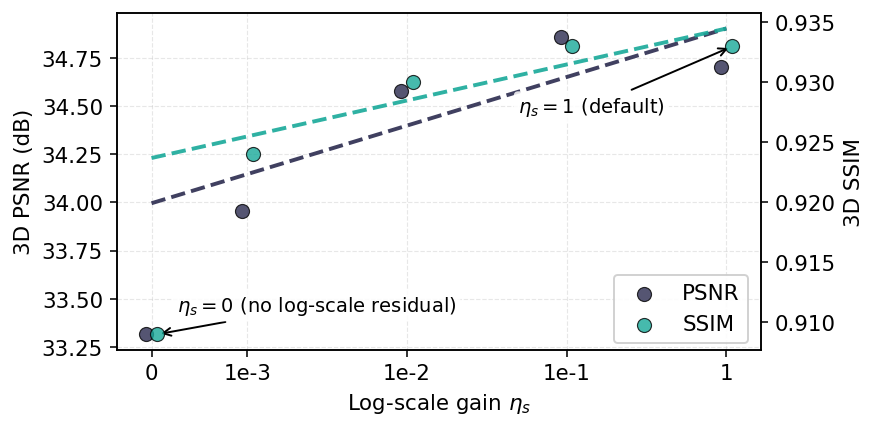

In [585]:
# ------------------------
# Plot: \eta_s sweep (log-scaled x-axis)
#   - show PSNR + SSIM (twin y-axis)
#   - simple linear fit on log10(eta_s) for eta_s > 0 (exclude eta_s=0 as a special point)
#   - annotate ONLY eta_s=0 and the default point (eta_s=1)
# ------------------------

eta = df_eta_s['eta_s'].to_numpy(dtype=float)
ps = df_eta_s['psnr3d'].to_numpy(dtype=float)
ss = df_eta_s['ssim3d'].to_numpy(dtype=float)

# Fit on eta_s > 0 (treat eta_s=0 as special point)
mask_fit = eta > 0
x_fit = np.log10(eta[mask_fit])
coef_ps = np.polyfit(x_fit, ps[mask_fit], deg=1)
coef_ss = np.polyfit(x_fit, ss[mask_fit], deg=1)

fig, ax1 = plt.subplots(figsize=(6.4, 3.2))
ax2 = ax1.twinx()

c_psnr = '#2b2b4f'
c_ssim = '#18a999'

# x for plotting: log10(eta_s) for eta_s>0, and a left margin point for eta_s=0
x0 = x_fit.min() - 0.6
x_center = np.where(eta > 0, np.log10(eta), x0)

# If two points look visually overlapped at the same x (twin y-axis), slightly offset them.
DX = 0.035
x_ps = x_center - DX
x_ss = x_center + DX

# Indices for special/default points
idx_zero = int(np.argmin(np.abs(eta - 0.0)))
idx_default = int(np.argmin(np.abs(eta - 1.0)))

# Scatter points (uniform round markers, normal size; use alpha + edge to keep visible)
S = 52
ALPHA = 0.80
EDGE = 'black'
LW = 0.6

ax1.scatter(
    x_ps, ps,
    s=S,
    marker='o',
    color=c_psnr,
    alpha=ALPHA,
    edgecolor=EDGE,
    linewidth=LW,
    zorder=6,
    label='PSNR',
)
ax2.scatter(
    x_ss, ss,
    s=S,
    marker='o',
    color=c_ssim,
    alpha=ALPHA,
    edgecolor=EDGE,
    linewidth=LW,
    zorder=7,
    label='SSIM',
)

# trend lines (eta_s>0) — extend visually to eta_s=0 position by extrapolation
xx = np.linspace(x0, x_fit.max(), 240)
ps_fit = np.polyval(coef_ps, xx)
ss_fit = np.polyval(coef_ss, xx)
ax1.plot(xx, ps_fit, linestyle='--', color=c_psnr, alpha=0.9, linewidth=2.0)
ax2.plot(xx, ss_fit, linestyle='--', color=c_ssim, alpha=0.9, linewidth=2.0)

# ticks/labels
ax1.set_xlabel(r'Log-scale gain $\eta_s$')
ax1.set_ylabel('3D PSNR (dB)')
ax2.set_ylabel('3D SSIM')

# custom ticks for {0,1e-3,1e-2,1e-1,1} (ticks placed at the CENTER positions)
tick_eta = np.array([0.0, 1e-3, 1e-2, 1e-1, 1.0])
tick_x = np.where(tick_eta > 0, np.log10(tick_eta), x0)
ax1.set_xticks(tick_x)
ax1.set_xticklabels(['0', '1e-3', '1e-2', '1e-1', '1'])

ax1.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

# Annotations (only eta_s=0 and default eta_s=1)
arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
box_kw = dict(boxstyle='round,pad=0.22', fc='white', ec='none', alpha=0.85)

ax2.annotate(
    r'$\eta_s=0$ (no log-scale residual)',
    xy=(x_ss[idx_zero], ss[idx_zero]),
    xytext=(10, 12),
    textcoords='offset points',
    fontsize=10,
    arrowprops=arrow_kw,
    bbox=box_kw,
)

ax2.annotate(
    r'$\eta_s=1$ (default)',
    xy=(x_ss[idx_default], ss[idx_default]),
    xytext=(-110, -34),
    textcoords='offset points',
    fontsize=10,
    arrowprops=arrow_kw,
    bbox=box_kw,
)

# Legend: merge handles from both axes so SSIM appears
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles=(h1 + h2),
    labels=(l1 + l2),
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    framealpha=0.9,
    borderaxespad=0.0,
)

fig.tight_layout()
out_png = out_dir / f'eta_s_sweep_case{CASE_ID}_150views_wt099_dr001_best3d.png'
out_pdf = out_dir / f'eta_s_sweep_case{CASE_ID}_150views_wt099_dr001_best3d.pdf'
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print('Saved:', out_png.resolve())
print('Saved:', out_pdf.resolve())
plt.show()

# $\eta_r$ sweep (fixed $w_T=0.99$, $\eta_s=1$, 150 views)

We sweep the **rotation gain** $\eta_r \in \{0, 10^{-2} \,(\text{default}), 5\times 10^{-2}, 10^{-1}, 1\}$ at fixed $w_T=0.99$ and $\eta_s=1$.

**Selection rule:** among evaluations with **`iter > 5000`**, pick the checkpoint with the **highest `ssim3d`** (and report the corresponding `psnr3d`).

In [586]:
# ------------------------
# Parse logs for \eta_r sweep
#   fixed: w_T=0.99, \eta_s=1
# ------------------------

ETA_R_SPECS = [
    {'eta_r': 0.0, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1_dr0_temporal.log'},
    # default run corresponds to eta_r = 1e-2
    {'eta_r': 1e-2, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_np0ns0_A0_temporal.log', 'tag': 'default (np0ns0_A0)'},
    {'eta_r': 5e-2, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1_dr5e-2_temporal.log'},
    {'eta_r': 1e-1, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1_dr1e-1_temporal.log'},
    {'eta_r': 1.0, 'path': LOG_DIR / f'20260125_sp50_case{CASE_ID}_wt099_ds1_dr1_temporal.log'},
]

rows_eta_r = []
for spec in ETA_R_SPECS:
    p = Path(spec['path'])
    if not p.exists():
        raise FileNotFoundError(f'Missing eta_r log: {p}')
    row = parse_best_from_log(p, AFTER_ITER)
    row['eta_r'] = float(spec['eta_r'])
    row['tag'] = spec.get('tag', 'sweep')
    rows_eta_r.append(row)

df_eta_r = pd.DataFrame(rows_eta_r).sort_values('eta_r').reset_index(drop=True)
df_eta_r

,best_iter,psnr3d,ssim3d,log_path,eta_r,tag
0,60000,34.555,0.933,log/20260125_sp50_case2_wt099_ds1_dr0_temporal...,0.00,sweep
1,60000,34.702,0.933,log/20260125_sp50_case2_np0ns0_A0_temporal.log,0.01,default (np0ns0_A0)
2,60000,34.646,0.933,log/20260125_sp50_case2_wt099_ds1_dr5e-2_tempo...,0.05,sweep
3,30000,34.660,0.931,log/20260125_sp50_case2_wt099_ds1_dr1e-1_tempo...,0.10,sweep
4,30000,33.577,0.916,log/20260125_sp50_case2_wt099_ds1_dr1_temporal...,1.00,sweep


In [587]:
# Save the parsed \eta_r sweep table
out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)
eta_r_csv = out_dir / f'eta_r_sweep_case{CASE_ID}_150views_wt099_ds1_best3d.csv'
df_eta_r.to_csv(eta_r_csv, index=False)
print('Saved:', eta_r_csv.resolve())

Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_r_sweep_case2_150views_wt099_ds1_best3d.csv


Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_r_sweep_case2_150views_wt099_ds1_best3d.png
Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/eta_r_sweep_case2_150views_wt099_ds1_best3d.pdf


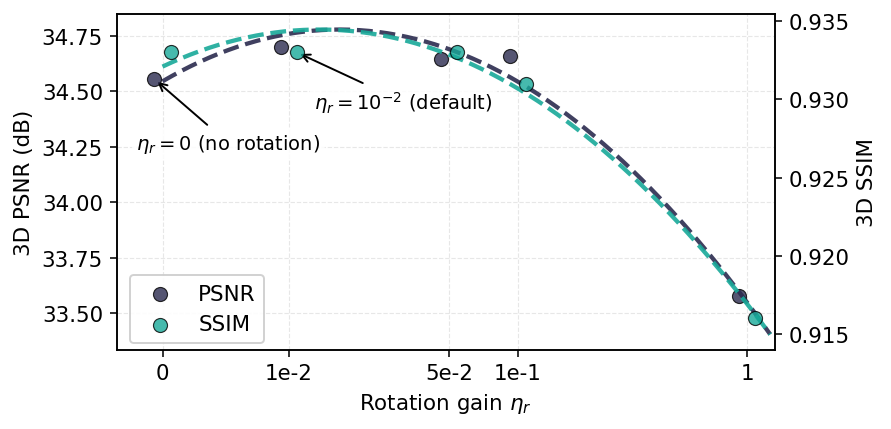

In [588]:
# ------------------------
# Plot: \eta_r sweep (log-scaled x-axis)
#   - show PSNR + SSIM (twin y-axis)
#   - draw two smooth dashed trend lines for PSNR and SSIM (not required to pass points)
#   - treat eta_r = 0 as a special point at the left margin
# ------------------------

eta = df_eta_r['eta_r'].to_numpy(dtype=float)
ps = df_eta_r['psnr3d'].to_numpy(dtype=float)
ss = df_eta_r['ssim3d'].to_numpy(dtype=float)

# Build x positions safely (avoid log10(0) warnings)
mask_pos = eta > 0
x_pos = np.log10(eta[mask_pos])

# Place eta_r=0 at a left margin position
x0 = float(x_pos.min() - 0.55)
x_center = np.empty_like(eta, dtype=float)
x_center[mask_pos] = np.log10(eta[mask_pos])
x_center[~mask_pos] = x0

# Slight x offset so the two metrics are visually distinguishable
DX = 0.035
x_ps = x_center - DX
x_ss = x_center + DX

# Indices for special/default points
idx_zero = int(np.argmin(np.abs(eta - 0.0)))
idx_default = int(np.argmin(np.abs(eta - 1e-2)))

fig, ax1 = plt.subplots(figsize=(6.4, 3.2))
ax2 = ax1.twinx()

c_psnr = '#2b2b4f'
c_ssim = '#18a999'

# Match marker style with other sweep plots
S = 52
ALPHA = 0.80
EDGE = 'black'
LW = 0.6

ax1.scatter(
    x_ps, ps,
    s=S,
    marker='o',
    color=c_psnr,
    alpha=ALPHA,
    edgecolor=EDGE,
    linewidth=LW,
    zorder=6,
    label='PSNR',
)
ax2.scatter(
    x_ss, ss,
    s=S,
    marker='o',
    color=c_ssim,
    alpha=ALPHA,
    edgecolor=EDGE,
    linewidth=LW,
    zorder=7,
    label='SSIM',
)

# ------------------------
# Smooth trend lines (PSNR / SSIM)
#   Fit quadratic curves in x-space (doesn't need to go through points).
#   Include the left special x0 point so the trends visually span to eta_r=0.
# ------------------------

deg = 2
if x_ps.size < deg + 1:
    raise RuntimeError('Not enough points to fit the smooth curve(s).')

coef_ps = np.polyfit(x_ps, ps, deg=deg)
coef_ss = np.polyfit(x_ss, ss, deg=deg)

xx = np.linspace(x0, float(x_pos.max() + 0.10), 260)
ps_fit = np.polyval(coef_ps, xx)
ss_fit = np.polyval(coef_ss, xx)

ax1.plot(
    xx, ps_fit,
    linestyle='--',
    color=c_psnr,
    alpha=0.90,
    linewidth=2.2,
    zorder=5,
)
ax2.plot(
    xx, ss_fit,
    linestyle='--',
    color=c_ssim,
    alpha=0.90,
    linewidth=2.2,
    zorder=5,
)

# ticks/labels
ax1.set_xlabel(r'Rotation gain $\eta_r$')
ax1.set_ylabel('3D PSNR (dB)')
ax2.set_ylabel('3D SSIM')

# custom ticks (removed 1e-3)
_tick_eta = np.array([0.0, 1e-2, 5e-2, 1e-1, 1.0])
_tick_x = np.array([x0, -2.0, np.log10(5e-2), -1.0, 0.0], dtype=float)
ax1.set_xticks(_tick_x)
ax1.set_xticklabels(['0', '1e-2', '5e-2', '1e-1', '1'])

# x-limits: leave a small margin so left annotation doesn't collide with frame
ax1.set_xlim(x0 - 0.20, float(x_pos.max() + 0.12))

ax1.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

# Annotations (eta_r=0 and default)
arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
box_kw = dict(boxstyle='round,pad=0.22', fc='white', ec='none', alpha=0.85)

# Place label text in axes-fraction coordinates to guarantee it stays inside the frame
# - First label: move closer to the point => shorter arrow
ax1.annotate(
    r'$\eta_r=0$ (no rotation)',
    xy=(x_ps[idx_zero], ps[idx_zero]),
    xycoords='data',
    xytext=(0.03, 0.65),
    textcoords='axes fraction',
    fontsize=10,
    ha='left',
    va='top',
    arrowprops=arrow_kw,
    bbox=box_kw,
    clip_on=True,
)

# - Second label: move slightly downward to avoid overlap with dashed curves
ax2.annotate(
    r'$\eta_r=10^{-2}$ (default)',
    xy=(x_ss[idx_default], ss[idx_default]),
    xycoords='data',
    xytext=(0.30, 0.70),
    textcoords='axes fraction',
    fontsize=10,
    ha='left',
    va='bottom',
    arrowprops=arrow_kw,
    bbox=box_kw,
    clip_on=True,
)

# Legend: merge handles from both axes so SSIM appears
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles=(h1 + h2),
    labels=(l1 + l2),
    loc='lower left',
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    framealpha=0.9,
    borderaxespad=0.0,
)

fig.tight_layout()
out_png = out_dir / f'eta_r_sweep_case{CASE_ID}_150views_wt099_ds1_best3d.png'
out_pdf = out_dir / f'eta_r_sweep_case{CASE_ID}_150views_wt099_ds1_best3d.pdf'
fig.savefig(out_png, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print('Saved:', out_png.resolve())
print('Saved:', out_pdf.resolve())
plt.show()

Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/case2_sp50_150views_abc_vector.pdf
Saved: /root/autodl-tmp/4dctgs/x2-gaussian-main-origin/figs/case2_sp50_150views_abc_vector.png


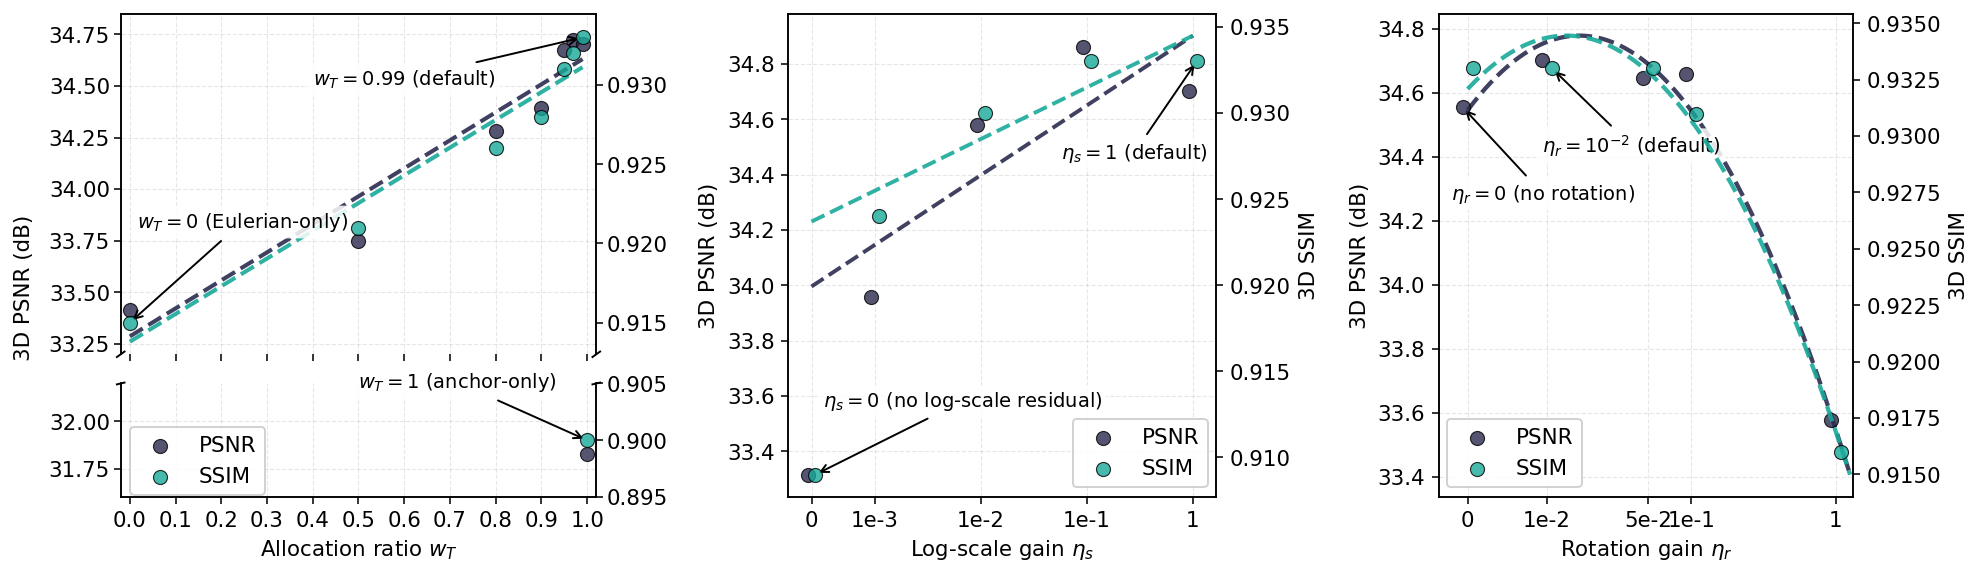

In [592]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Vector multi-panel figure (no titles / no a,b,c)
#   - draw directly from data/code (NOT loading PNG)
#   - save vector PDF
# ------------------------

out_dir = Path('figs')
out_dir.mkdir(parents=True, exist_ok=True)

if 'df' not in globals():
    raise RuntimeError('Missing df (w_T sweep). Run the parsing cells first.')
if 'df_eta_s' not in globals():
    raise RuntimeError('Missing df_eta_s (eta_s sweep). Run the parsing cells first.')
if 'df_eta_r' not in globals():
    raise RuntimeError('Missing df_eta_r (eta_r sweep). Run the parsing cells first.')

CASE_ID = globals().get('CASE_ID', 2)


def plot_wt(subfig):
    _df = df.copy()
    _df = _df[['wT', 'psnr3d', 'ssim3d']].copy().dropna()
    _df['wT'] = _df['wT'].astype(float)
    _df['psnr3d'] = _df['psnr3d'].astype(float)
    _df['ssim3d'] = _df['ssim3d'].astype(float)

    _df = _df.sort_values('wT').drop_duplicates(subset=['wT'], keep='last').reset_index(drop=True)

    wt = _df['wT'].to_numpy(dtype=float)
    y_psnr = _df['psnr3d'].to_numpy(dtype=float)
    y_ssim = _df['ssim3d'].to_numpy(dtype=float)

    mask_fit = wt < 1.0 - 1e-12
    if mask_fit.sum() < 2:
        raise RuntimeError('Need at least 2 points with w_T < 1.0 to fit trend lines.')

    coef_psnr = np.polyfit(wt[mask_fit], y_psnr[mask_fit], deg=1)
    coef_ssim = np.polyfit(wt[mask_fit], y_ssim[mask_fit], deg=1)

    xx = np.linspace(wt[mask_fit].min(), wt[mask_fit].max(), 200)
    psnr_fit = np.polyval(coef_psnr, xx)
    ssim_fit = np.polyval(coef_ssim, xx)

    idx_w0 = int(np.argmin(np.abs(wt - 0.0)))
    idx_w099 = int(np.argmin(np.abs(wt - 0.99)))
    idx_w1 = int(np.argmin(np.abs(wt - 1.0)))

    wt_0, ssim_0 = float(wt[idx_w0]), float(y_ssim[idx_w0])
    wt_099, ssim_099 = float(wt[idx_w099]), float(y_ssim[idx_w099])
    wt_1, ssim_1 = float(wt[idx_w1]), float(y_ssim[idx_w1])

    c_psnr = '#2b2b4f'
    c_ssim = '#18a999'

    S = 52
    ALPHA = 0.80
    EDGE = 'black'
    LW = 0.6

    (ax_top, ax_bot) = subfig.subplots(
        2, 1, sharex=True,
        gridspec_kw={'height_ratios': [3.0, 1.0], 'hspace': 0.05},
    )
    ax2_top = ax_top.twinx()
    ax2_bot = ax_bot.twinx()

    # Avoid y-label/tick overlap (both left PSNR and right SSIM)
    ax_top.tick_params(axis='y', pad=2)
    ax_bot.tick_params(axis='y', pad=2)
    ax2_top.tick_params(axis='y', pad=2)
    ax2_bot.tick_params(axis='y', pad=2)

    ax_top.scatter(wt, y_psnr, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')
    ax_bot.scatter(wt, y_psnr, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')
    ax2_top.scatter(wt, y_ssim, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')
    ax2_bot.scatter(wt, y_ssim, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')

    ax_top.plot(xx, psnr_fit, linestyle='--', color=c_psnr, alpha=0.9, linewidth=2.1, zorder=2)
    ax2_top.plot(xx, ssim_fit, linestyle='--', color=c_ssim, alpha=0.9, linewidth=2.1, zorder=2)

    ax_top.set_ylim(33.2, 34.85)
    ax2_top.set_ylim(0.913, 0.9345)
    ax_bot.set_ylim(31.6, 32.2)
    ax2_bot.set_ylim(0.895, 0.905)

    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax2_top.spines['bottom'].set_visible(False)
    ax2_bot.spines['top'].set_visible(False)

    ax_top.tick_params(labeltop=False)
    ax_bot.xaxis.tick_bottom()

    d = 0.008
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1.0)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    ax_top.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)
    ax_bot.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

    ax_top.set_ylabel('')
    ax2_top.set_ylabel('')
    ax_bot.set_ylabel('')
    ax2_bot.set_ylabel('')

    ax_bot.set_xlim(-0.02, 1.02)
    ticks = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 1)
    ax_bot.set_xticks(ticks)
    ax_bot.set_xticklabels([f'{t:.1f}' for t in ticks])
    ax_bot.set_xlabel(r'Allocation ratio $w_T$')

    arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
    box_kw = dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85)

    ann_fs = 10
    ax2_top.annotate(
        r'$w_T=0$ (Eulerian-only)',
        xy=(wt_0, ssim_0),
        xytext=(0.015, 0.921),
        textcoords='data',
        fontsize=ann_fs,
        arrowprops=arrow_kw,
        bbox=box_kw,
    )

    ax2_top.annotate(
        r'$w_T=0.99$ (default)',
        xy=(wt_099, ssim_099),
        xytext=(0.40, 0.930),
        textcoords='data',
        fontsize=ann_fs,
        arrowprops=arrow_kw,
        bbox=box_kw,
    )

    ax2_bot.annotate(
        r'$w_T=1$ (anchor-only)',
        xy=(wt_1, ssim_1),
        xytext=(0.50, 0.9046),
        textcoords='data',
        fontsize=ann_fs,
        arrowprops=arrow_kw,
        bbox=box_kw,
    )

    h1, l1 = ax_bot.get_legend_handles_labels()
    h2, l2 = ax2_bot.get_legend_handles_labels()
    ax_bot.legend(
        handles=(h1 + h2),
        labels=(l1 + l2),
        loc='lower left',
        bbox_to_anchor=(0.02, 0.02),
        frameon=True,
        framealpha=0.9,
        borderaxespad=0.0,
    )

    # Figure-level y labels (push SSIM further right to avoid overlap)
    subfig.text(-0.03, 0.5, '3D PSNR (dB)', rotation=90, va='center', ha='center')
    subfig.text(1.06, 0.5, '3D SSIM', rotation=270, va='center', ha='center')



def plot_eta_s(subfig):
    eta = df_eta_s['eta_s'].to_numpy(dtype=float)
    ps = df_eta_s['psnr3d'].to_numpy(dtype=float)
    ss = df_eta_s['ssim3d'].to_numpy(dtype=float)

    mask_pos = eta > 0
    x_pos = np.log10(eta[mask_pos])

    x0 = float(x_pos.min() - 0.6)
    x_center = np.empty_like(eta, dtype=float)
    x_center[mask_pos] = np.log10(eta[mask_pos])
    x_center[~mask_pos] = x0

    DX = 0.035
    x_ps = x_center - DX
    x_ss = x_center + DX

    mask_fit = eta > 0
    x_fit = np.log10(eta[mask_fit])
    coef_ps = np.polyfit(x_fit, ps[mask_fit], deg=1)
    coef_ss = np.polyfit(x_fit, ss[mask_fit], deg=1)

    ax1 = subfig.subplots(1, 1)
    ax2 = ax1.twinx()

    c_psnr = '#2b2b4f'
    c_ssim = '#18a999'

    S = 52
    ALPHA = 0.80
    EDGE = 'black'
    LW = 0.6

    ax1.scatter(x_ps, ps, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')
    ax2.scatter(x_ss, ss, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')

    xx = np.linspace(x0, x_fit.max(), 240)
    ps_fit = np.polyval(coef_ps, xx)
    ss_fit = np.polyval(coef_ss, xx)
    ax1.plot(xx, ps_fit, linestyle='--', color=c_psnr, alpha=0.9, linewidth=2.0)
    ax2.plot(xx, ss_fit, linestyle='--', color=c_ssim, alpha=0.9, linewidth=2.0)

    ax1.set_xlabel(r'Log-scale gain $\eta_s$')
    ax1.set_ylabel('3D PSNR (dB)')
    ax2.set_ylabel('3D SSIM')

    tick_eta = np.array([0.0, 1e-3, 1e-2, 1e-1, 1.0])
    tick_x = np.array([x0, -3.0, -2.0, -1.0, 0.0], dtype=float)
    ax1.set_xticks(tick_x)
    ax1.set_xticklabels(['0', '1e-3', '1e-2', '1e-1', '1'])

    ax1.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

    idx_zero = int(np.argmin(np.abs(eta - 0.0)))
    idx_default = int(np.argmin(np.abs(eta - 1.0)))

    arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
    box_kw = dict(boxstyle='round,pad=0.22', fc='white', ec='none', alpha=0.85)

    ax2.annotate(
        r'$\eta_s=0$ (no log-scale residual)',
        xy=(x_ss[idx_zero], ss[idx_zero]),
        xytext=(4, 35),
        textcoords='offset points',
        fontsize=10,
        arrowprops=arrow_kw,
        bbox=box_kw,
    )

    ax2.annotate(
        r'$\eta_s=1$ (default)',
        xy=(x_ss[idx_default], ss[idx_default]),
        xytext=(-70, -50),
        textcoords='offset points',
        fontsize=10,
        arrowprops=arrow_kw,
        bbox=box_kw,
    )

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles=(h1 + h2),
        labels=(l1 + l2),
        loc='lower right',
        bbox_to_anchor=(0.98, 0.02),
        frameon=True,
        framealpha=0.9,
        borderaxespad=0.0,
    )



def plot_eta_r(subfig):
    eta = df_eta_r['eta_r'].to_numpy(dtype=float)
    ps = df_eta_r['psnr3d'].to_numpy(dtype=float)
    ss = df_eta_r['ssim3d'].to_numpy(dtype=float)

    mask_pos = eta > 0
    x_pos = np.log10(eta[mask_pos])

    x0 = float(x_pos.min() - 0.55)
    x_center = np.empty_like(eta, dtype=float)
    x_center[mask_pos] = np.log10(eta[mask_pos])
    x_center[~mask_pos] = x0

    DX = 0.035
    x_ps = x_center - DX
    x_ss = x_center + DX

    idx_zero = int(np.argmin(np.abs(eta - 0.0)))
    idx_default = int(np.argmin(np.abs(eta - 1e-2)))

    ax1 = subfig.subplots(1, 1)
    ax2 = ax1.twinx()

    c_psnr = '#2b2b4f'
    c_ssim = '#18a999'

    S = 52
    ALPHA = 0.80
    EDGE = 'black'
    LW = 0.6

    ax1.scatter(x_ps, ps, s=S, marker='o', color=c_psnr, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=6, label='PSNR')
    ax2.scatter(x_ss, ss, s=S, marker='o', color=c_ssim, alpha=ALPHA, edgecolor=EDGE, linewidth=LW, zorder=7, label='SSIM')

    deg = 2
    if x_ps.size < deg + 1:
        raise RuntimeError('Not enough points to fit the smooth curve(s).')

    coef_ps = np.polyfit(x_ps, ps, deg=deg)
    coef_ss = np.polyfit(x_ss, ss, deg=deg)

    xx = np.linspace(x0, float(x_pos.max() + 0.10), 260)
    ps_fit = np.polyval(coef_ps, xx)
    ss_fit = np.polyval(coef_ss, xx)

    ax1.plot(xx, ps_fit, linestyle='--', color=c_psnr, alpha=0.90, linewidth=2.2, zorder=5)
    ax2.plot(xx, ss_fit, linestyle='--', color=c_ssim, alpha=0.90, linewidth=2.2, zorder=5)

    ax1.set_xlabel(r'Rotation gain $\eta_r$')
    ax1.set_ylabel('3D PSNR (dB)')
    ax2.set_ylabel('3D SSIM')

    _tick_x = np.array([x0, -2.0, np.log10(5e-2), -1.0, 0.0], dtype=float)
    ax1.set_xticks(_tick_x)
    ax1.set_xticklabels(['0', '1e-2', '5e-2', '1e-1', '1'])

    ax1.set_xlim(x0 - 0.20, float(x_pos.max() + 0.12))
    ax1.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.30)

    arrow_kw = dict(arrowstyle='->', lw=1.0, color='black')
    box_kw = dict(boxstyle='round,pad=0.22', fc='white', ec='none', alpha=0.85)

    ax1.annotate(
        r'$\eta_r=0$ (no rotation)',
        xy=(x_ps[idx_zero], ps[idx_zero]),
        xycoords='data',
        xytext=(0.03, 0.65),
        textcoords='axes fraction',
        fontsize=10,
        ha='left',
        va='top',
        arrowprops=arrow_kw,
        bbox=box_kw,
        clip_on=True,
    )

    ax2.annotate(
        r'$\eta_r=10^{-2}$ (default)',
        xy=(x_ss[idx_default], ss[idx_default]),
        xycoords='data',
        xytext=(0.25, 0.70),
        textcoords='axes fraction',
        fontsize=10,
        ha='left',
        va='bottom',
        arrowprops=arrow_kw,
        bbox=box_kw,
        clip_on=True,
    )

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles=(h1 + h2),
        labels=(l1 + l2),
        loc='lower left',
        bbox_to_anchor=(0.02, 0.02),
        frameon=True,
        framealpha=0.9,
        borderaxespad=0.0,
    )


# ---- build the 1x3 panel as true vector plots
fig = plt.figure(figsize=(13.8, 4.0), constrained_layout=True)
subfigs = fig.subfigures(1, 3, wspace=0.03)

plot_wt(subfigs[0])
plot_eta_s(subfigs[1])
plot_eta_r(subfigs[2])

out_pdf = out_dir / 'case2_sp50_150views_abc_vector.pdf'
out_png = out_dir / 'case2_sp50_150views_abc_vector.png'
fig.savefig(out_pdf, bbox_inches='tight', pad_inches=0.02)
fig.savefig(out_png, bbox_inches='tight', pad_inches=0.02, dpi=200)
print('Saved:', out_pdf.resolve())
print('Saved:', out_png.resolve())
plt.show()